### Homework 5 - advanced macroeconomics 1

**Task 2**: Pick data on real GDP from some country (annual data). You will have to filter the data to obtain the cyclical component. Estimate the process for TFP. Do all the tasks in estimation: priors check, identification, convergence, and compute the Bayesian IRFs. In this script i will make the first part of the task until the estimation of the process for TFP. From that i will work on DYNARE.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# GDP serie that i will use: PIB - preços de mercado (preços 2010) - R$ de 2010 - 
# Instituto Brasileiro de Geografia e Estatística- Sistema de Contas Nacionais (IBGE/SCN Anual) - SCN10_PIBP10

pib = pd.read_csv('ipeadata_pibreal2010.csv')
print(pib)

     Data  \
0    1900   
1    1901   
2    1902   
3    1903   
4    1904   
..    ...   
119  2019   
120  2020   
121  2021   
122  2022   
123  2023   

     PIB - preços de mercado (preços 2010) - R$ de 2010 - Instituto Brasileiro de Geografia e Estatística- Sistema de Contas Nacionais (IBGE/SCN Anual) - SCN10_PIBP10  \
0                                         2.170338e+04                                                                                                                   
1                                         2.482099e+04                                                                                                                   
2                                         2.470108e+04                                                                                                                   
3                                         2.518072e+04                                                                                                             

In [6]:
pib.dtypes            # type of variables

Data                                                                                                                                                                   int64
PIB - preços de mercado (preços 2010) - R$ de 2010 - Instituto Brasileiro de Geografia e Estatística- Sistema de Contas Nacionais (IBGE/SCN Anual) - SCN10_PIBP10    float64
Unnamed: 2                                                                                                                                                           float64
dtype: object

In [8]:
pib.columns = ['Ano', 'PIB', 'Descartar']    # rename the second column as 'PIB'

pib['Ano'] = pd.to_datetime(pib['Ano'], format='%Y')  # Convert the column 'Ano' to datetime

pib = pib.drop(columns=['Descartar'])          # droping this unuseful columns

# Reordering and defining as index the date (ano) 
pib = pib.set_index('Ano')

print(pib.head())

                     PIB
Ano                     
1900-01-01  21703.379822
1901-01-01  24820.992393
1902-01-01  24701.084217
1903-01-01  25180.716921
1904-01-01  25540.441448


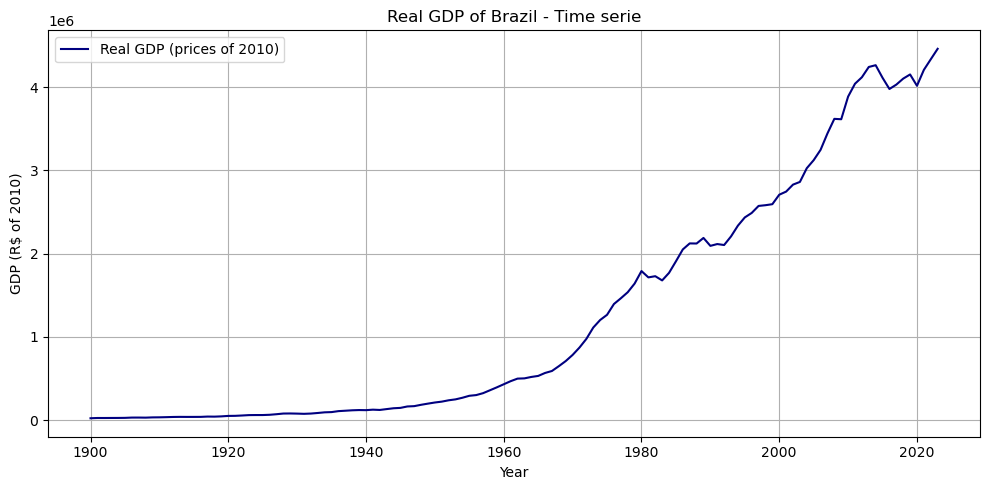

In [12]:
# plot the gdp serie
plt.figure(figsize=(10, 5))
plt.plot(pib.index, pib['PIB'], label='Real GDP (prices of 2010)', color='navy')
plt.title('Real GDP of Brazil - Time serie')
plt.xlabel('Year')
plt.ylabel('GDP (R$ of 2010)')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig('real_gdp_brazil.png', dpi=300)
plt.show()

In [18]:
import os        # to see where the picture goes
os.getcwd()

'C:\\Users\\KAWAN'

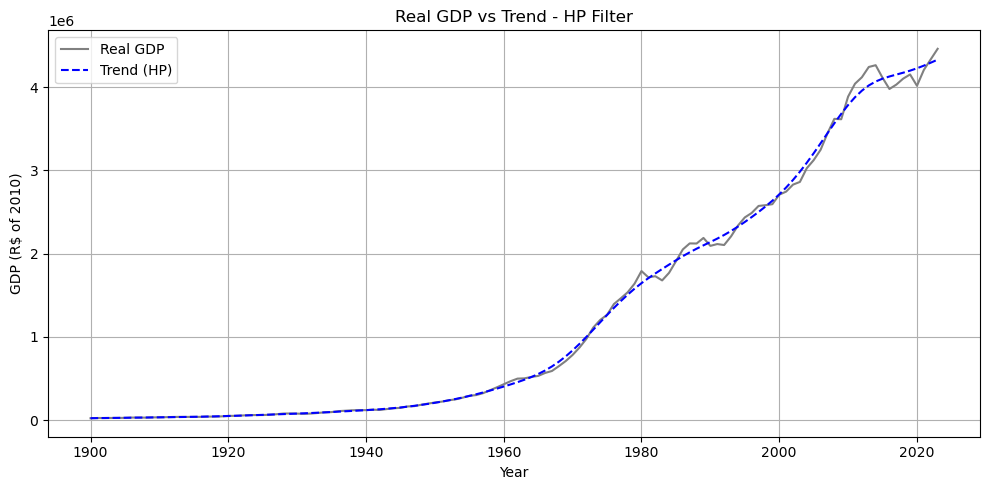

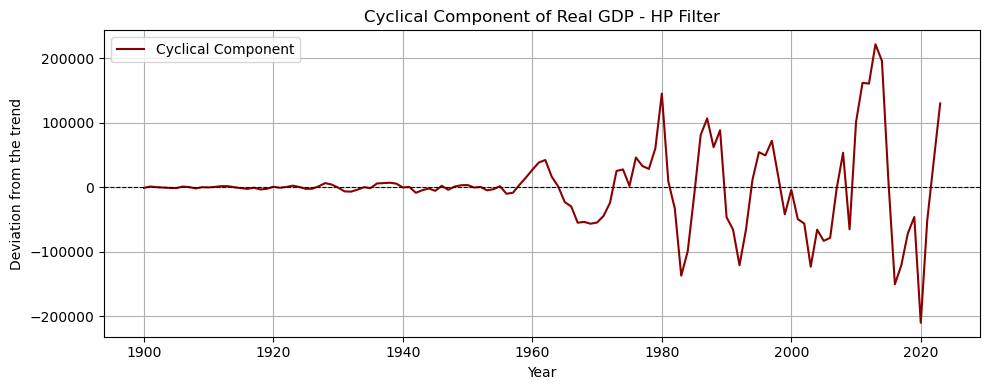

In [20]:
from statsmodels.tsa.filters.hp_filter import hpfilter

# applying HP filter to GDP data
cycle, trend = hpfilter(pib['PIB'], lamb=100)  # lambda=100 to annual data

pib['PIB_tendencia'] = trend      # adding the columns to the df
pib['PIB_ciclo'] = cycle

# ploting trend and GDP
plt.figure(figsize=(10, 5))
plt.plot(pib.index, pib['PIB'], label='Real GDP', color='gray')
plt.plot(pib.index, pib['PIB_tendencia'], label='Trend (HP)', color='blue', linestyle='--')
plt.title('Real GDP vs Trend - HP Filter')
plt.xlabel('Year')
plt.ylabel('GDP (R$ of 2010)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('pib_tendencia.png', dpi=300)
plt.show()

# ploting the cyclical part of the GDP
plt.figure(figsize=(10, 4))
plt.plot(pib.index, pib['PIB_ciclo'], label='Cyclical Component', color='darkred')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Cyclical Component of Real GDP - HP Filter')
plt.xlabel('Year')
plt.ylabel('Deviation from the trend')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig('pib_ciclo.png', dpi=300)
plt.show()

In [22]:
# Preparing the data

pib['log_PIB'] = np.log(pib['PIB'])      # applies log on GDP before HP Filter

cycle, trend = hpfilter(pib['log_PIB'], lamb=100)   # Reaplies the HP filter in the log of GDP
pib['TFP'] = cycle                                  # proxy of a_t (the process of the TFP)

In [24]:
print(pib)

                     PIB  PIB_tendencia      PIB_ciclo    log_PIB       TFP
Ano                                                                        
1900-01-01  2.170338e+04   2.238058e+04    -677.201624   9.985223 -0.041550
1901-01-01  2.482099e+04   2.337238e+04    1448.616475  10.119445  0.054606
1902-01-01  2.470108e+04   2.435740e+04     343.685843  10.114602  0.012114
1903-01-01  2.518072e+04   2.534336e+04    -162.646041  10.133834 -0.006019
1904-01-01  2.554044e+04   2.634142e+04    -800.979241  10.148018 -0.029166
...                  ...            ...            ...        ...       ...
2019-01-01  4.151725e+06   4.197607e+06  -45882.285619  15.239034 -0.012023
2020-01-01  4.015683e+06   4.225610e+06 -209927.820255  15.205718 -0.051633
2021-01-01  4.206934e+06   4.257829e+06  -50895.812842  15.252245 -0.012361
2022-01-01  4.333844e+06   4.293062e+06   40781.733874  15.281965  0.009415
2023-01-01  4.459893e+06   4.329598e+06  130295.007047  15.310635  0.029842

[124 rows x

In [34]:
# saving the cycle as TFP to import in octave
# pib[['TFP']].to_csv('tfp_brasil.csv')

In [26]:
print(len(pib))

124


In [28]:
pib = pib.rename(columns={'TFP': 'a'})  # rename to the used in .mod
pib['date'] = pib.index                 # if the date is in the index
print(pib)

                     PIB  PIB_tendencia      PIB_ciclo    log_PIB         a  \
Ano                                                                           
1900-01-01  2.170338e+04   2.238058e+04    -677.201624   9.985223 -0.041550   
1901-01-01  2.482099e+04   2.337238e+04    1448.616475  10.119445  0.054606   
1902-01-01  2.470108e+04   2.435740e+04     343.685843  10.114602  0.012114   
1903-01-01  2.518072e+04   2.534336e+04    -162.646041  10.133834 -0.006019   
1904-01-01  2.554044e+04   2.634142e+04    -800.979241  10.148018 -0.029166   
...                  ...            ...            ...        ...       ...   
2019-01-01  4.151725e+06   4.197607e+06  -45882.285619  15.239034 -0.012023   
2020-01-01  4.015683e+06   4.225610e+06 -209927.820255  15.205718 -0.051633   
2021-01-01  4.206934e+06   4.257829e+06  -50895.812842  15.252245 -0.012361   
2022-01-01  4.333844e+06   4.293062e+06   40781.733874  15.281965  0.009415   
2023-01-01  4.459893e+06   4.329598e+06  130295.0070

In [30]:
tfp_br = pib[['date', 'a']]        # selecting the two columns that will be in the csv file imported in Octave
print(tfp_br)

                 date         a
Ano                            
1900-01-01 1900-01-01 -0.041550
1901-01-01 1901-01-01  0.054606
1902-01-01 1902-01-01  0.012114
1903-01-01 1903-01-01 -0.006019
1904-01-01 1904-01-01 -0.029166
...               ...       ...
2019-01-01 2019-01-01 -0.012023
2020-01-01 2020-01-01 -0.051633
2021-01-01 2021-01-01 -0.012361
2022-01-01 2022-01-01  0.009415
2023-01-01 2023-01-01  0.029842

[124 rows x 2 columns]


In [34]:
import os                                
os.getcwd()

'C:\\Users\\KAWAN'

In [29]:
# changing directory
os.chdir("C:/Users/KAWAN/Downloads") 

In [33]:
tfp_br.to_csv('tfp_br.csv', index=False)